# 2. Convergence and cost

Every fixed-step method should reach its theoretical order: 4 for RK4 and GL2, 6 for GL3. This notebook measures it on one radial period of the strong-field orbit $(p, e) = (7.5, 0.5)$, then compares the cost of reaching a given error, counted in vector-field evaluations, with the adaptive DOP853. Figures F4 and F6 do the same with more methods and cases.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from geoint.plotting import style

style.apply()
%matplotlib inline

In [2]:
from geoint.experiments import RunSpec, run_many
from geoint.testcases.schwarzschild import Eccentric

case = Eccentric(7.5, 0.5, n_orbits=1.0)
steps = [100, 160, 250, 400, 630, 1000, 1600, 2500]
fixed = run_many(
    [RunSpec.make(case, "b", m, n_steps=n) for m in ("RK4", "GL2", "GL3") for n in steps]
)
adaptive = run_many(
    [RunSpec.make(case, "b", "DOP853", rtol=t, atol=t) for t in np.geomspace(1e-4, 1e-13, 10)]
)

GL2: measured order 4.00 +- 0.00
GL3: measured order 6.04 +- 0.01
RK4: measured order 4.02 +- 0.00


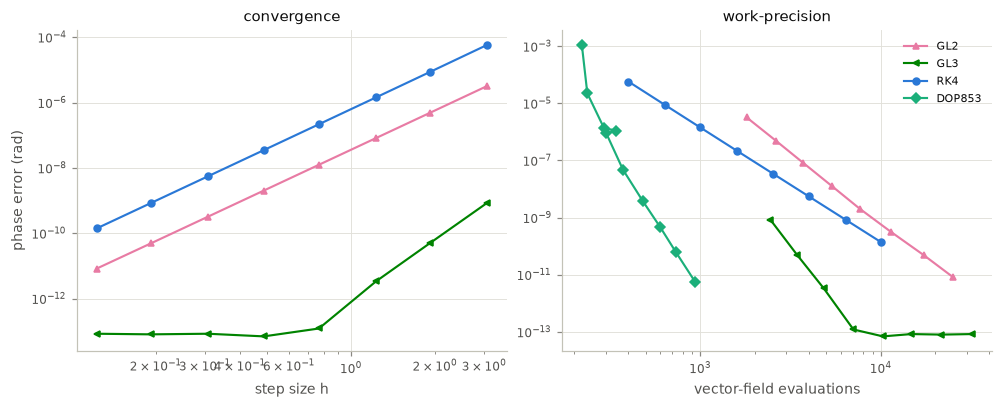

In [3]:
from geoint.experiments.analysis import fit_slope

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), constrained_layout=True)
for m, g in fixed.groupby("method"):
    axes[0].loglog(g["h"], g["error"], **style.method_style(m), label=m)
    slope, se, _ = fit_slope(g["h"], g["error"])
    print(f"{m}: measured order {slope:.2f} +- {se:.2f}")
axes[0].set(xlabel="step size h", ylabel="phase error (rad)", title="convergence")
for m, g in [*fixed.groupby("method"), ("DOP853", adaptive)]:
    axes[1].loglog(g["nfev"], g["error"], **style.method_style(m), label=m)
axes[1].set(xlabel="vector-field evaluations", title="work-precision")
axes[1].legend();

On this short problem the adaptive eighth-order pair reaches any accuracy for far fewer evaluations than the fixed-step methods. Over thousands of orbits the picture changes (notebook 3).